In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

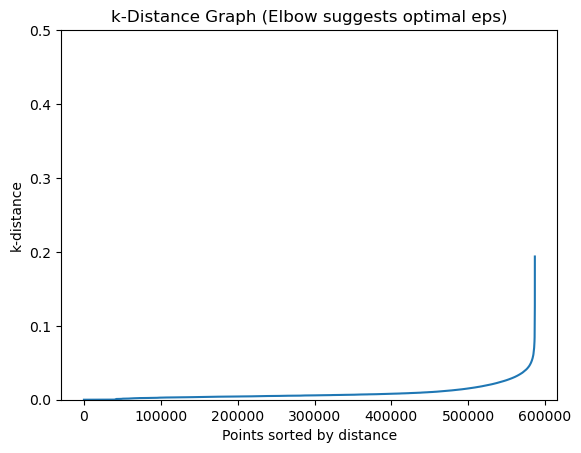

In [3]:
df2 = pd.read_csv('tracks.csv')
df = df2.drop(columns=['id', 'name', 'artists', 'id_artists', 'release_date'])
df=df[['danceability','energy','instrumentalness','acousticness']]
from sklearn.neighbors import NearestNeighbors

k = 2
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df)
distances, indices = neighbors_fit.kneighbors(df)

distances = np.sort(distances[:, k-1], axis=0)
fig, ax = plt.subplots()
ax.set_ylim(0, 0.5)
plt.plot(distances)
plt.ylabel('k-distance')
plt.xlabel('Points sorted by distance')
plt.title('k-Distance Graph (Elbow suggests optimal eps)')
plt.show()

In [3]:
df.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [14]:

epsilon = 0.05  # Chosen based on k-distance graph
min_samples = 8  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(df)
# Assign cluster labels
df['Cluster'] = dbscan.labels_

print(df['Cluster'].value_counts())


 0     42342
-1      7399
 6        23
 8        21
 3        20
 1        16
 14       15
 13       14
 17       11
 2        11
 10        8
 25        8
 24        8
 20        8
 11        8
 9         8
 4         8
 5         8
 18        7
 15        7
 22        7
 26        7
 23        6
 19        6
 16        6
 21        5
 27        5
 12        5
 7         4
Name: Cluster, dtype: int64


In [15]:
if len(set(dbscan.labels_)) > 1:
    score = silhouette_score(df, dbscan.labels_)
    print(f'Silhouette Score: {score:.4f}')
else:
    print("Only one cluster found; adjust eps or min_samples.")

Silhouette Score: 0.4974


In [6]:
df.head(20)

,danceability,energy,instrumentalness,acousticness,Cluster
0,0.645,0.4450,0.744000,0.674,-1
1,0.695,0.2630,0.000000,0.797,0
2,0.434,0.1770,0.021800,0.994,0
3,0.321,0.0946,0.918000,0.995,0
4,0.402,0.1580,0.130000,0.989,0
5,0.227,0.2610,0.247000,0.994,0
6,0.510,0.3550,0.000000,0.965,0
7,0.563,0.1840,0.000016,0.993,0
8,0.488,0.4750,0.006450,0.620,0
9,0.548,0.0391,0.933000,0.996,0


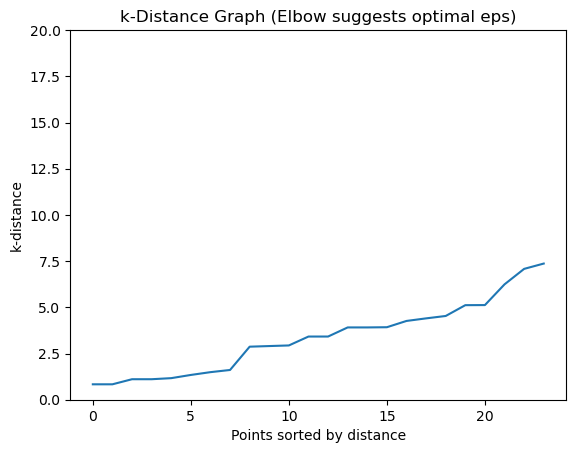

In [9]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
df2 = pd.read_csv('playlist_exit_ticket.csv')
df = df2[['average_danceability','top_key','average_tempo','top_time_signature']]
from sklearn.neighbors import NearestNeighbors

k = 5  # Typical choice: min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df)
distances, indices = neighbors_fit.kneighbors(df)

# Sort distances for visualization
distances = np.sort(distances[:, k-1], axis=0)
fig, ax = plt.subplots()
ax.set_ylim(0, 20)
plt.plot(distances)
plt.ylabel('k-distance')
plt.xlabel('Points sorted by distance')
plt.title('k-Distance Graph (Elbow suggests optimal eps)')
plt.show()

In [19]:
epsilon = 12  # Chosen based on k-distance graph
min_samples = 8  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(df)
# Assign cluster labels
df['Cluster'] = dbscan.labels_

print(df['Cluster'].value_counts())

0    24
Name: Cluster, dtype: int64


C:\Users\phowlett\AppData\Local\Temp\ipykernel_4724\4059808650.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = dbscan.labels_


In [20]:
if len(set(dbscan.labels_)) > 1:
    score = silhouette_score(df, dbscan.labels_)
    print(f'Silhouette Score: {score:.4f}')
else:
    print("Only one cluster found; adjust eps or min_samples.")

Only one cluster found; adjust eps or min_samples.


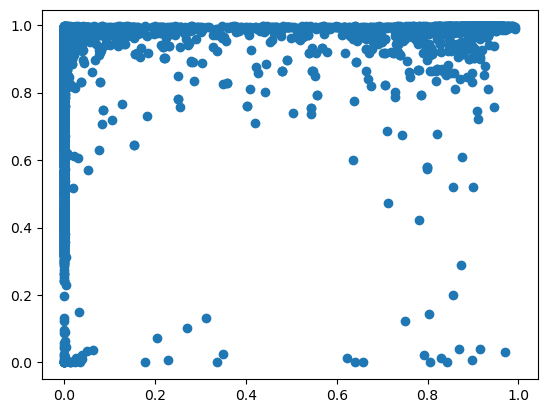

In [15]:
plt.scatter(df['instrumentalness'], df['acousticness'])
plt.show()

In [11]:
df.head(10000)

,danceability,energy,instrumentalness,acousticness
0,0.645,0.4450,0.744000,0.674
1,0.695,0.2630,0.000000,0.797
2,0.434,0.1770,0.021800,0.994
3,0.321,0.0946,0.918000,0.995
4,0.402,0.1580,0.130000,0.989
...,...,...,...,...
9995,0.638,0.1960,0.000000,0.724
9996,0.727,0.1970,0.000004,0.750
9997,0.450,0.1080,0.275000,0.995
9998,0.547,0.1520,0.001490,0.987


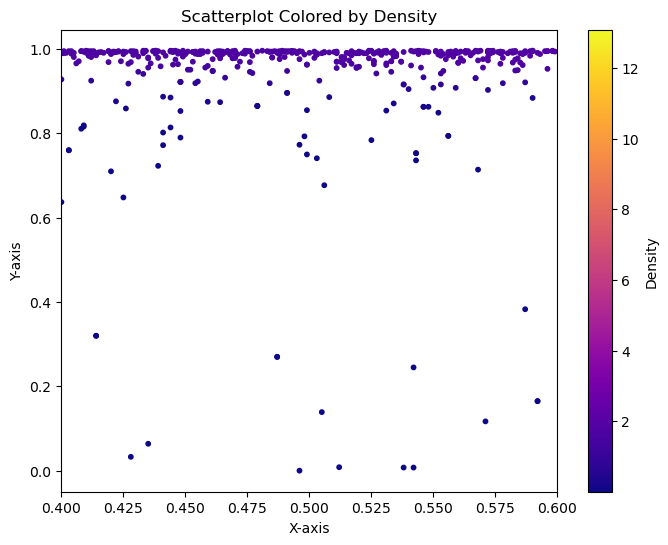

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
df=df.truncate(after=10000)
xy = np.vstack([df['instrumentalness'], df['acousticness']])
density = gaussian_kde(xy)(xy)

# Create scatter plot with density-based coloring
plt.figure(figsize=(8, 6))
plt.xlim(0.4,0.6)
plt.scatter(df['instrumentalness'], df['acousticness'], c=density, cmap='plasma', s=10)  # 'plasma' colormap gives a good density gradient
plt.colorbar(label='Density')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatterplot Colored by Density')
plt.show()

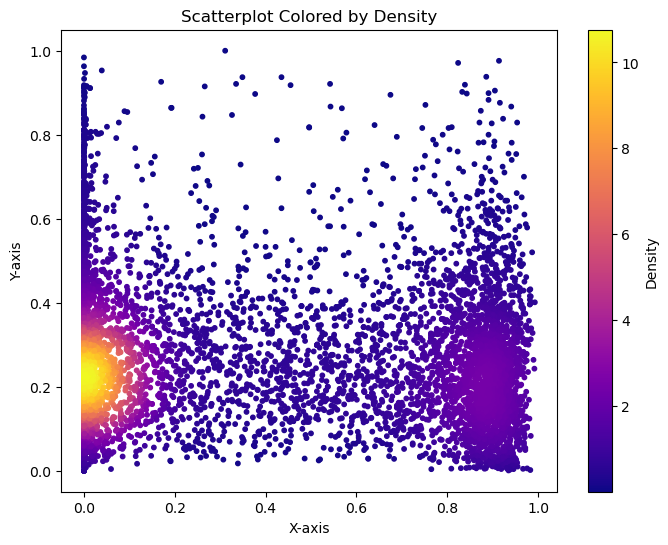

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
df=df.truncate(after=10000)
xy = np.vstack([df['instrumentalness'], df['energy']])
density = gaussian_kde(xy)(xy)

# Create scatter plot with density-based coloring
plt.figure(figsize=(8, 6))
plt.scatter(df['instrumentalness'], df['energy'], c=density, cmap='plasma', s=10)  # 'plasma' colormap gives a good density gradient
plt.colorbar(label='Density')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatterplot Colored by Density')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
df2 = pd.read_csv('tracks.csv')
df = df2.drop(columns=['id', 'name', 'artists', 'id_artists', 'release_date'])
df=df[['danceability','energy','instrumentalness','acousticness']]
df=df.truncate(after=50000)


In [10]:
pd.set_option('display.max_rows', None)

In [12]:
print(df)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [4]:
import pandas as pd
import json
playlist = json.load(open("vetting_playlist.json"))['tracks']['items']

In [5]:
print(playlist)

[{'added_at': '2017-06-23T23:21:59Z', 'added_by': {'external_urls': {'spotify': 'https://open.spotify.com/user/1225630715'}, 'href': 'https://api.spotify.com/v1/users/1225630715', 'id': '1225630715', 'type': 'user', 'uri': 'spotify:user:1225630715'}, 'is_local': False, 'primary_color': None, 'track': {'preview_url': None, 'available_markets': [], 'explicit': False, 'type': 'track', 'episode': False, 'track': True, 'album': {'available_markets': [], 'type': 'album', 'album_type': 'album', 'href': 'https://api.spotify.com/v1/albums/6SIib5yrq0saKy08p2IPrB', 'id': '6SIib5yrq0saKy08p2IPrB', 'images': [{'height': 640, 'url': 'https://i.scdn.co/image/ab67616d0000b273c48375f67f100f88207b54bc', 'width': 640}, {'height': 300, 'url': 'https://i.scdn.co/image/ab67616d00001e02c48375f67f100f88207b54bc', 'width': 300}, {'height': 64, 'url': 'https://i.scdn.co/image/ab67616d00004851c48375f67f100f88207b54bc', 'width': 64}], 'name': 'Bad Self Portraits', 'release_date': '2014-02-18', 'release_date_preci

In [6]:
df_final = pd.concat([df, df2['id']], axis=1)
df_final.head()

,danceability,energy,instrumentalness,acousticness,id
0,0.645,0.4450,0.7440,0.674,35iwgR4jXetI318WEWsa1Q
1,0.695,0.2630,0.0000,0.797,021ht4sdgPcrDgSk7JTbKY
2,0.434,0.1770,0.0218,0.994,07A5yehtSnoedViJAZkNnc
3,0.321,0.0946,0.9180,0.995,08FmqUhxtyLTn6pAh6bk45
4,0.402,0.1580,0.1300,0.989,08y9GfoqCWfOGsKdwojr5e


In [8]:
import json
import pandas as pd

# Load the JSON file
with open('vetting_playlist.json', 'r') as f:
    data = json.load(f)

# Extract track items
track_items = data['tracks']['items']

# Flatten the relevant fields into a DataFrame
vetting = pd.DataFrame([
    {
        'added_at': item['added_at'],
        'added_by': item['added_by']['id'],
        'track_name': item['track']['name'],
        'track_id': item['track']['id'],
        'artist_name': ', '.join(artist['name'] for artist in item['track']['artists']),
        'album_name': item['track']['album']['name'],
        'duration_ms': item['track']['duration_ms'],
        'explicit': item['track']['explicit'],
        'popularity': item['track']['popularity'],
        'spotify_url': item['track']['external_urls']['spotify']
    }
    for item in track_items if 'track' in item
])

# Display the first few rows
vetting.head()

,added_at,added_by,track_name,track_id,artist_name,album_name,duration_ms,explicit,popularity,spotify_url
0,2017-06-23T23:21:59Z,1225630715,Better Than,0NSEZeWHkYCknk1nAVO1Fh,Lake Street Dive,Bad Self Portraits,215879,False,0,https://open.spotify.com/track/0NSEZeWHkYCknk1...
1,2017-04-21T17:02:44Z,1225630715,Only For You,17ZnveSDBpG9QtL7zLJNPy,Heartless Bastards,Arrow,308066,False,0,https://open.spotify.com/track/17ZnveSDBpG9QtL...
2,2017-06-12T22:46:03Z,1225630715,Back Pocket,1DrlLvlYd1FIjNavRm6NdX,Vulfpeck,Thrill of the Arts,181259,False,61,https://open.spotify.com/track/1DrlLvlYd1FIjNa...
3,2017-04-15T00:53:05Z,1225630715,Dunes,51ggEZWbFP5dMdWjGCDYTk,Alabama Shakes,Sound & Color,257920,False,0,https://open.spotify.com/track/51ggEZWbFP5dMdW...
4,2017-06-29T23:13:06Z,1225630715,All The Time,40WXqoyOLAAugGmJWZU1FY,Bahamas,Bahamas is Afie,234973,False,18,https://open.spotify.com/track/40WXqoyOLAAugGm...


In [ ]:
for i in range(len(vetting)):
    for x in range(len(df_final)):
        if vetting.loc[i][3] == df_final.loc[x][4]:
            print(df_final.loc[x][4])

1DrlLvlYd1FIjNavRm6NdX


In [ ]:
df_final.head()